In [7]:
import pandas as pd

train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")

In [8]:
numerical_train= train.select_dtypes(include=["int64", "float64"])
correlation=numerical_train.corr()["SalePrice"].sort_values(ascending=False)
correlation

correlation.head(10)


SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

In [10]:
correlation[correlation.abs() < 0.1].sort_values()

MSSubClass     -0.084284
OverallCond    -0.077856
YrSold         -0.028923
LowQualFinSF   -0.025606
Id             -0.021917
MiscVal        -0.021190
BsmtHalfBath   -0.016844
BsmtFinSF2     -0.011378
3SsnPorch       0.044584
MoSold          0.046432
PoolArea        0.092404
Name: SalePrice, dtype: float64

In [11]:
correlation[correlation < 0].sort_values()

KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
MSSubClass      -0.084284
OverallCond     -0.077856
YrSold          -0.028923
LowQualFinSF    -0.025606
Id              -0.021917
MiscVal         -0.021190
BsmtHalfBath    -0.016844
BsmtFinSF2      -0.011378
Name: SalePrice, dtype: float64

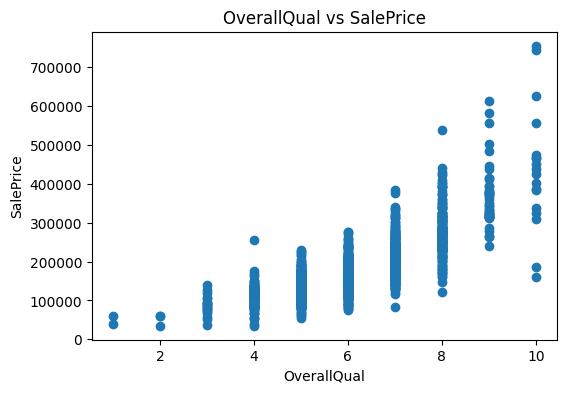

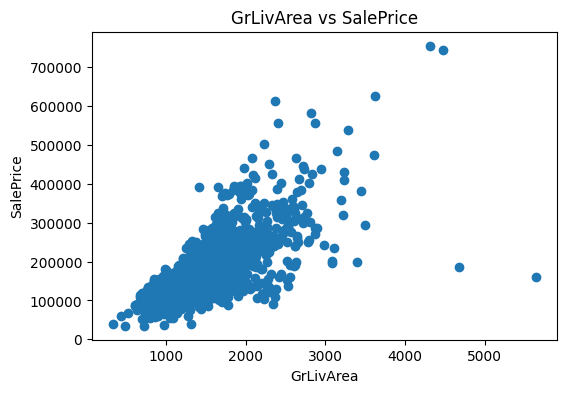

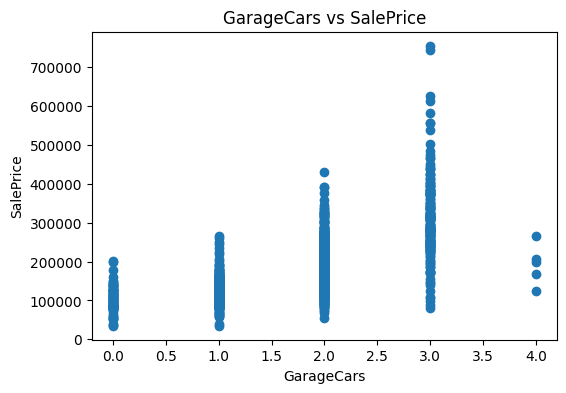

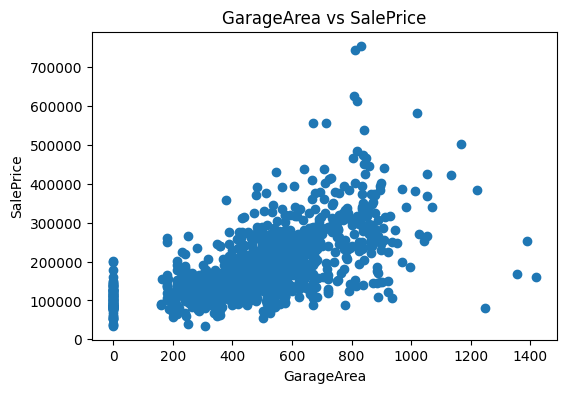

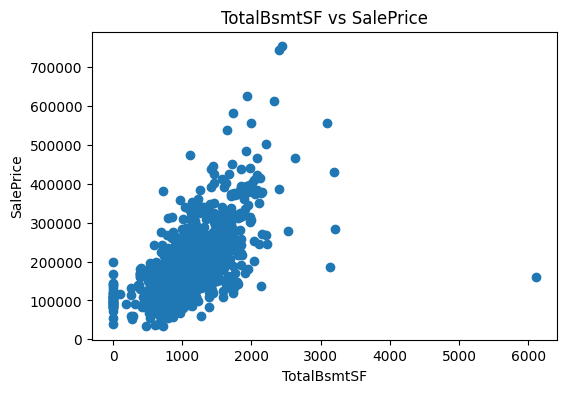

In [12]:
import matplotlib.pyplot as plt

features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF"
]

for feature in features:
    plt.figure(figsize=(6, 4))
    plt.scatter(train[feature], train["SalePrice"])
    plt.xlabel(feature)
    plt.ylabel("SalePrice")
    plt.title(f"{feature} vs SalePrice")
    plt.show()

## Scatter Plot Observations

### OverallQual vs SalePrice

`OverallQual` shows a very clear positive relationship with `SalePrice`. As the overall quality rating increases, the sale price generally increases. This confirms that house quality is one of the strongest numerical predictors of house price.

The points appear in vertical groups because `OverallQual` is a discrete rating variable, not a continuous variable. Overall, houses with higher quality ratings tend to have much higher prices.

---

### GrLivArea vs SalePrice

`GrLivArea` shows a strong positive relationship with `SalePrice`. Houses with larger above-ground living areas generally sell for higher prices.

However, the scatter plot shows some possible outliers. A few houses have very large living areas but relatively low sale prices. These observations should be investigated later because they may affect the performance of regression models.

---

### GarageCars vs SalePrice

`GarageCars` has a positive relationship with `SalePrice`. Houses with higher garage capacity usually have higher sale prices.

The points are grouped because `GarageCars` is a discrete variable, usually taking values such as 0, 1, 2, 3, or 4. The relationship is useful, but it is not perfectly linear.

---

### GarageArea vs SalePrice

`GarageArea` also shows a positive relationship with `SalePrice`. Larger garage areas are generally associated with higher house prices.

However, there is some variation in the points, meaning that garage area alone does not fully explain the sale price. This feature may be more useful when combined with other variables such as `OverallQual`, `GrLivArea`, and `GarageCars`.

---

### TotalBsmtSF vs SalePrice

`TotalBsmtSF` shows a positive relationship with `SalePrice`. Houses with larger basement areas tend to sell for higher prices.

There are also some houses with little or no basement area, and some large basements with different sale prices. This suggests that basement size is useful, but it is not enough by itself to predict house price accurately.

---

## General Observation

The scatter plots confirm the correlation results. The strongest numerical relationships with `SalePrice` are related to house quality, living area, garage capacity, garage size, and basement size.

Overall, bigger and higher-quality houses tend to sell for higher prices. Some possible outliers, especially in `GrLivArea`, should be investigated later before training regression models.


Average SalePrice by Neighborhood:


Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Somerst    225379.837209
ClearCr    212565.428571
Crawfor    210624.725490
CollgCr    197965.773333
Blmngtn    194870.882353
Gilbert    192854.506329
NWAmes     189050.068493
SawyerW    186555.796610
Mitchel    156270.122449
NAmes      145847.080000
NPkVill    142694.444444
SWISU      142591.360000
Blueste    137500.000000
Sawyer     136793.135135
OldTown    128225.300885
Edwards    128219.700000
BrkSide    124834.051724
BrDale     104493.750000
IDOTRR     100123.783784
MeadowV     98576.470588
Name: SalePrice, dtype: float64


Average SalePrice by KitchenQual:


KitchenQual
Ex    328554.670000
Gd    212116.023891
TA    139962.511565
Fa    105565.205128
Name: SalePrice, dtype: float64


Average SalePrice by ExterQual:


...


Average SalePrice by CentralAir:


CentralAir
Y    186186.709890
N    105264.073684
Name: SalePrice, dtype: float64


Average SalePrice by SaleCondition:


SaleCondition
Partial    272291.752000
Normal     175202.219533
Alloca     167377.416667
Family     149600.000000
Abnorml    146526.623762
AdjLand    104125.000000
Name: SalePrice, dtype: float64

<Figure size 1000x500 with 0 Axes>

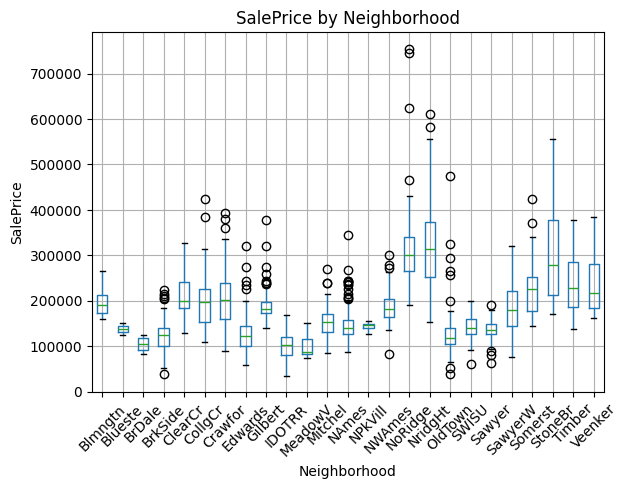

<Figure size 1000x500 with 0 Axes>

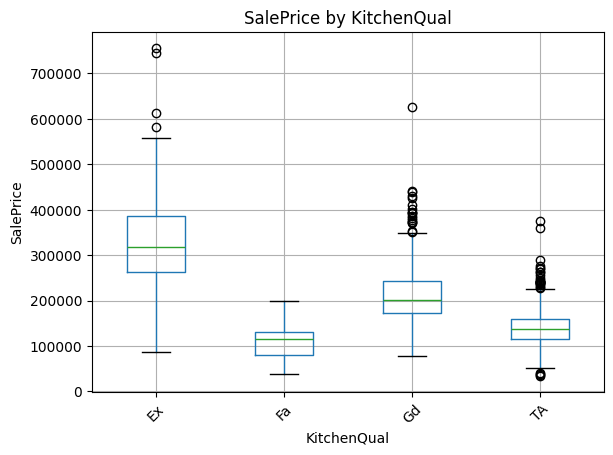

<Figure size 1000x500 with 0 Axes>

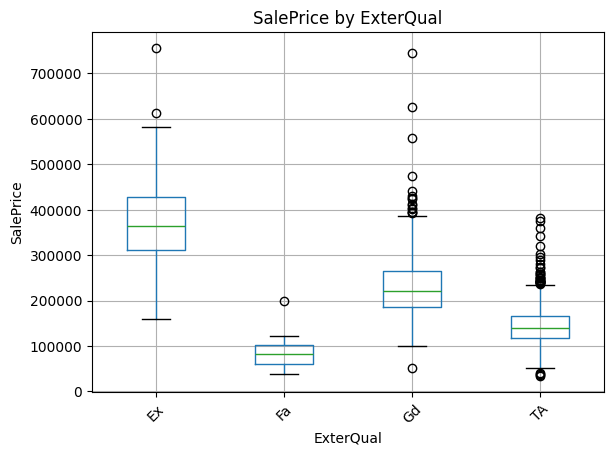

<Figure size 1000x500 with 0 Axes>

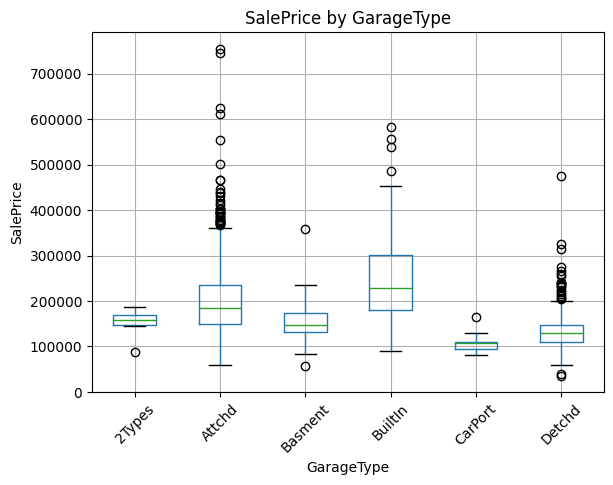

<Figure size 1000x500 with 0 Axes>

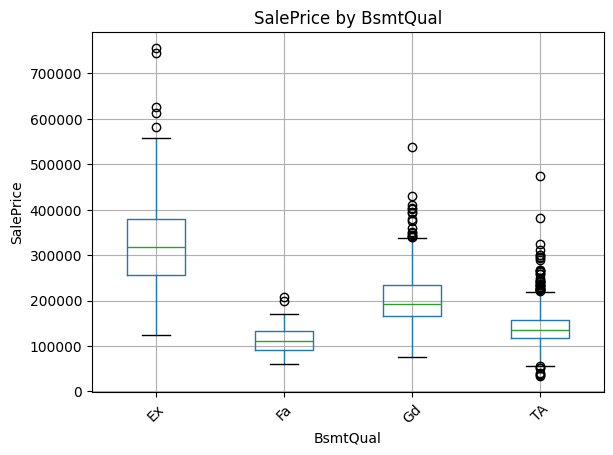

<Figure size 1000x500 with 0 Axes>

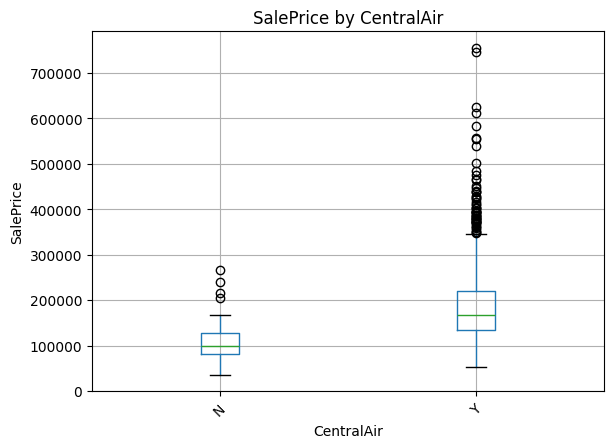

<Figure size 1000x500 with 0 Axes>

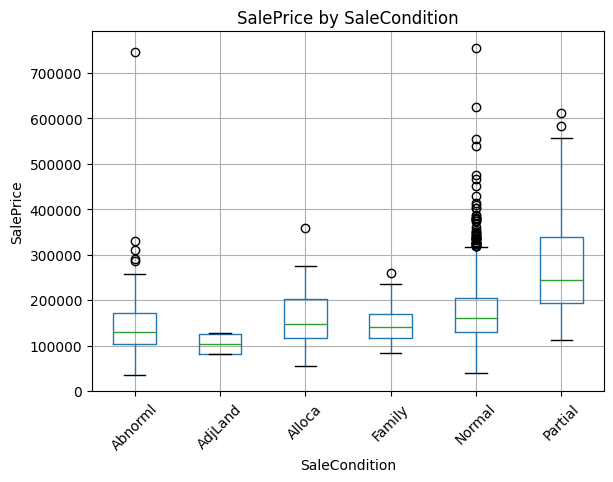

In [13]:
categorical_features = [
    "Neighborhood",
    "KitchenQual",
    "ExterQual",
    "GarageType",
    "BsmtQual",
    "CentralAir",
    "SaleCondition"
]
for feature in categorical_features:
    print(f"\nAverage SalePrice by {feature}:")
    display(
        train.groupby(feature)["SalePrice"]
        .mean()
        .sort_values(ascending=False)
    )

for feature in categorical_features:
    plt.figure(figsize=(10, 5))
    train.boxplot(column="SalePrice", by=feature)
    plt.title(f"SalePrice by {feature}")
    plt.suptitle("")
    plt.xlabel(feature)
    plt.ylabel("SalePrice")
    plt.xticks(rotation=45)
    plt.show()

## Categorical Feature Observations

### Neighborhood
Some neighborhoods have much higher average SalePrice than others, which suggests that location is an important predictor.

### KitchenQual
Houses with better kitchen quality tend to have higher SalePrice.

### ExterQual
Better exterior quality is associated with higher SalePrice.

### GarageType
Some garage types are associated with higher prices, while houses with no garage or less desirable garage types tend to have lower prices.

### BsmtQual
Better basement quality is associated with higher SalePrice.

### CentralAir
Houses with central air conditioning tend to have higher SalePrice than houses without it.

### SaleCondition
Some sale conditions are associated with higher or lower prices, but this feature may need more careful interpretation.

## Phase 3 Summary

### Strong Numerical Predictors

The strongest numerical predictors of `SalePrice` appear to be:

- `OverallQual`
- `GrLivArea`
- `GarageCars`
- `GarageArea`
- `TotalBsmtSF`
- `1stFlrSF`
- `FullBath`
- `TotRmsAbvGrd`
- `YearBuilt`

These features show moderate to strong positive relationships with `SalePrice`. In general, houses with higher quality, larger living areas, larger garages, larger basements, more bathrooms, and newer construction years tend to sell for higher prices.

### Weak Numerical Predictors

Some numerical features have weak correlations with `SalePrice`, such as:

- `MoSold`
- `YrSold`
- `MiscVal`
- `Id`
- `BsmtFinSF2`
- `LowQualFinSF`

These features do not show a strong linear relationship with house price.

### Important Categorical Predictors

Some categorical features appear important because they create clear differences in sale price between groups.

Examples include:

- `Neighborhood`
- `KitchenQual`
- `ExterQual`
- `BsmtQual`
- `GarageType`
- `CentralAir`
- `SaleCondition`

For example, `KitchenQual` shows a clear relationship with `SalePrice`: houses with excellent kitchen quality generally have much higher prices than houses with typical or fair kitchen quality.

### Possible Outliers

Some possible outliers were observed, especially in the relationship between `GrLivArea` and `SalePrice`. A few houses have very large living areas but relatively low sale prices. These points should be investigated later before training regression models.

### Main Patterns Discovered

The main pattern is that bigger, newer, and higher-quality houses tend to sell for higher prices. House quality, living area, garage size, basement size, and location-related variables seem especially important for predicting `SalePrice`.

### Questions for Next Phase

The next phase should focus on preparing the data for modeling. This will include handling missing values, encoding categorical variables, treating skewed variables if needed, and preparing the dataset for regression models.